In [1]:
import json

In [20]:
# 1. Define your neighbor pairs (Province A, Province B)
# China has many neighbors; here is a starter list for the North/East regions
neighbor_pairs = [
    # North China
    ("Beijing", "Tianjin"), ("Beijing", "Hebei"), ("Tianjin", "Hebei"),
    ("Hebei", "Shanxi"), ("Hebei", "Henan"), ("Hebei", "Shandong"), 
    ("Hebei", "Liaoning"), ("Hebei", "Innermongolia"),
    ("Shanxi", "Innermongolia"), ("Shanxi", "Shaanxi"), ("Shanxi", "Henan"),
    ("Innermongolia", "Heilongjiang"), ("Innermongolia", "Jilin"), 
    ("Innermongolia", "Liaoning"), ("Innermongolia", "Ningxia"), 
    ("Innermongolia", "Gansu"), ("Innermongolia", "Shaanxi"),

    # Northeast
    ("Liaoning", "Jilin"), ("Jilin", "Heilongjiang"),

    # East China
    ("Shanghai", "Jiangsu"), ("Shanghai", "Zhejiang"),
    ("Jiangsu", "Zhejiang"), ("Jiangsu", "Anhui"), ("Jiangsu", "Shandong"),
    ("Zhejiang", "Anhui"), ("Zhejiang", "Fujian"), ("Zhejiang", "Jiangxi"),
    ("Anhui", "Henan"), ("Anhui", "Hubei"), ("Anhui", "Jiangxi"), ("Anhui", "Shandong"),
    ("Fujian", "Jiangxi"), ("Fujian", "Guangdong"),
    ("Shandong", "Henan"),

    # Central China
    ("Henan", "Hubei"), ("Henan", "Shaanxi"),
    ("Hubei", "Hunan"), ("Hubei", "Chongqing"), ("Hubei", "Shaanxi"), ("Hubei", "Jiangxi"),
    ("Hunan", "Jiangxi"), ("Hunan", "Guangdong"), ("Hunan", "Guangxi"), 
    ("Hunan", "Guizhou"), ("Hunan", "Chongqing"),

    # South China
    ("Guangdong", "Jiangxi"), ("Guangdong", "Guangxi"), ("Guangdong", "Hainan"), ("Guangxi", "Hainan"), # Note: Hainan is via ferry/bridge

    # Southwest
    ("Chongqing", "Sichuan"), ("Chongqing", "Guizhou"), ("Chongqing", "Shaanxi"),
    ("Sichuan", "Guizhou"), ("Sichuan", "Yunnan"), ("Sichuan", "Tibet"), 
    ("Sichuan", "Gansu"), ("Sichuan", "Qinghai"), ("Sichuan", "Shaanxi"),
    ("Guizhou", "Yunnan"), ("Guizhou", "Guangxi"),
    ("Yunnan", "Guangxi"), ("Yunnan", "Tibet"),
    ("Tibet", "Xinjiang"), ("Tibet", "Qinghai"),

    # Northwest
    ("Shaanxi", "Ningxia"), ("Shaanxi", "Gansu"),
    ("Gansu", "Ningxia"), ("Gansu", "Xinjiang"), ("Gansu", "Qinghai"),
    ("Ningxia", "Innermongolia"),
    ("Xinjiang", "Qinghai")
]

In [21]:
province_mapping = {
    "Beijing": "Region1Beijing",
    "Tianjin": "Region2Tianjin",
    "Hebei": "Region3Hebei",
    "Shanxi": "Region4Shanxi",
    "Innermongolia": "Region5Innermongolia",
    "Liaoning": "Region6Liaoning",
    "Jilin": "Region7Jilin",
    "Heilongjiang": "Region8Heilongjiang",
    "Shanghai": "Region9Shanghai",
    "Jiangsu": "Region10Jiangsu",
    "Zhejiang": "Region11Zhejiang",
    "Anhui": "Region12Anhui",
    "Fujian": "Region13Fujian",
    "Jiangxi": "Region14Jiangxi",
    "Shandong": "Region15Shandong",
    "Henan": "Region16Henan",
    "Hubei": "Region17Hubei",
    "Hunan": "Region18Hunan",
    "Guangdong": "Region19Guangdong",
    "Guangxi": "Region20Guangxi",
    "Hainan": "Region21Hainan",
    "Chongqing": "Region22Chongqing",
    "Sichuan": "Region23Sichuan",
    "Guizhou": "Region24Guizhou",
    "Yunnan": "Region25Yunnan",
    "Tibet": "Region26Tibet",
    "Shaanxi": "Region27Shaanxi",
    "Gansu": "Region28Gansu",
    "Qinghai": "Region29Qinghai",
    "Ningxia": "Region30Ningxia",
    "Xinjiang": "Region31Xinjiang"
}

In [22]:
def generate_scrap_json(file_path):
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)

        # 2. Reset the instance_data list to start fresh
        new_instances = []

        # 3. Iterate through pairs and build the dictionary objects
        for p1, p2 in neighbor_pairs:
            province1 = province_mapping.get(p1)
            province2 = province_mapping.get(p2)
            entry = {
                "id": f"steelscrap_transport_{province1}_to_{province2}",
                "edges": {
                    "transmission_edge": {
                        "start_vertex": f"steelscrap_source_{province1}",
                        "end_vertex": f"steelscrap_source_{province2}"
                    }
                }
            }
            new_instances.append(entry)

        # 4. Update the main object
        data["transmission"]["instance_data"] = new_instances

        # 5. Save back to the file
        new_file_path = file_path.split('.')[0] + '_changed.json'
        with open(new_file_path, 'w') as f:
            json.dump(data, f, indent=4)
        
        print(f"Successfully generated {len(new_instances)} connections.")

    except (FileNotFoundError, KeyError) as e:
        print(f"Error: Ensure the file exists and matches the provided structure. {e}")

In [23]:
generate_scrap_json('assets/assets_1/scrap_transport_old.json')

Successfully generated 71 connections.


/var/folders/kh/f9wk57gd0fdfn4y132cdphgw0000gp/T/ipykernel_32566/938793476.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  china['centroid'] = china.geometry.centroid
/var/folders/kh/f9wk57gd0fdfn4y132cdphgw0000gp/T/ipykernel_32566/938793476.py:50: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  china.centroid.plot(ax=ax, marker='o', color='#d62728', markersize=20)


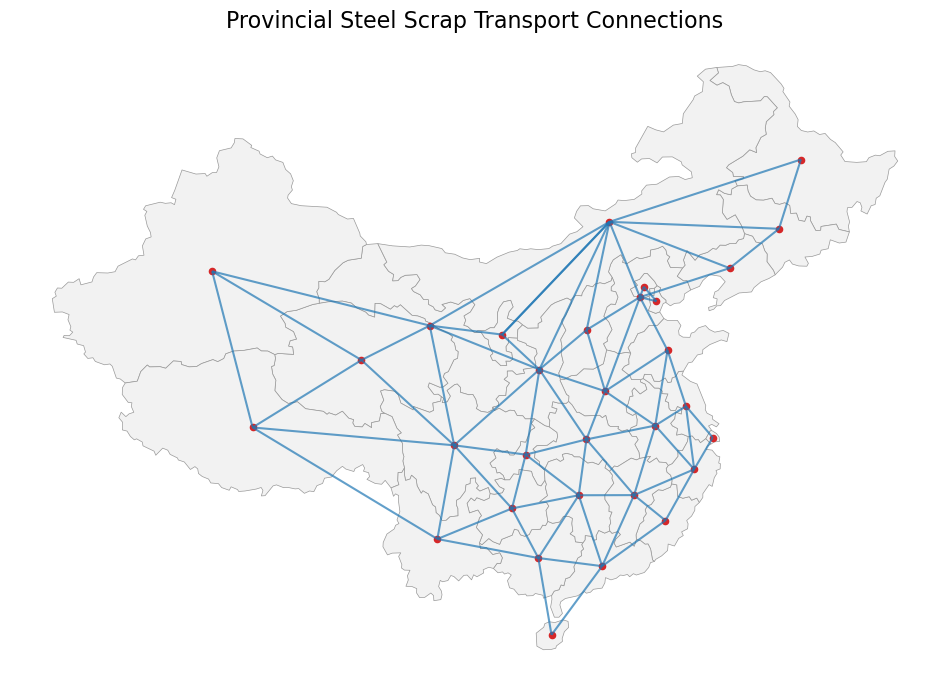

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# 1. Load your specific GeoJSON file
# This file contains the 'NAME_1' property we will use for mapping
china = gpd.read_file('gadm36_CHN_1.json')

# 2. Define the Mapping Dictionary 
# Keys = Names used in your transport data (JSON/List)
# Values = Names exactly as they appear in NAME_1 of the GeoJSON
mapping_dict = {
    "InnerMongolia": "Nei Mongol",
    "Tibet": "Xizang",
    "Ningxia": "Ningxia Hui",
    "Xinjiang": "Xinjiang Uygur",
    "Guangxi": "Guangxi",
    # Most others (Beijing, Anhui, etc.) usually match NAME_1 directly
}


# Apply the mapping
mapped_pairs = [
    (mapping_dict.get(p1, p1), mapping_dict.get(p2, p2)) 
    for p1, p2 in neighbor_pairs
]

# 4. Calculate Centroids based on the NAME_1 column
china['centroid'] = china.geometry.centroid
coords = dict(zip(china['NAME_1'], china['centroid']))

# 5. Build the Link geometries
lines = []
for p1, p2 in mapped_pairs:
    if p1 in coords and p2 in coords:
        lines.append(LineString([coords[p1], coords[p2]]))
    else:
        # Debugging: show if any names still don't match
        if p1 not in coords: print(f"Missing in GeoJSON: {p1}")
        if p2 not in coords: print(f"Missing in GeoJSON: {p2}")

edges_gdf = gpd.GeoDataFrame(geometry=lines, crs=china.crs)

# 6. Plot
fig, ax = plt.subplots(figsize=(12, 10))
china.plot(ax=ax, color='#f2f2f2', edgecolor='#999999', linewidth=0.5)
edges_gdf.plot(ax=ax, color='#1f77b4', linewidth=1.5, alpha=0.7, label='Scrap Transport Path')

# Add node points
china.centroid.plot(ax=ax, marker='o', color='#d62728', markersize=20)

plt.title("Provincial Steel Scrap Transport Connections", fontsize=16)
plt.axis('off')
plt.show()